In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

/Users/peter/opt/anaconda3/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [ ]:
def calculate_ipv_uncertainty(tenors, yields_A, yields_B, spreads_bps):
    """
    Applies Gaussian Process Regression to calculate the consensus yield curve
    and the pricing uncertainty (Observability Score).

    :param tenors: list or array of maturities (e.g., [1, 5, 10, 15, 30])
    :param yields_A: Yields from Source A (in %)
    :param yields_B: Yields from Source B (in %)
    :param spreads_bps: Bid-Ask spreads (in basis points)
    """

    # 1. Prepare the Data
    # We stack Source A and Source B data together so the model sees all quotes
    X_train = np.concatenate([tenors, tenors]).reshape(-1, 1)
    y_train = np.concatenate([yields_A, yields_B])

    # 2. Define the Observation Noise (alpha)
    spreads_pct = spreads_bps / 100.0
    bid_ask_variance = (spreads_pct / 2.0)**2
    
    # B. Variance due à la Divergence des Sources (Désaccord des brokers)
    # Ecart absolu entre Source A et Source B
    divergence_pct = np.abs(yields_A - yields_B)
    divergence_variance = (divergence_pct / 2.0)**2
    
    # C. Variance Totale = Illiquidité + Divergence
    total_variance = bid_ask_variance + divergence_variance
    
    alpha_noise = np.concatenate([total_variance, total_variance])
    
    # On met à l'échelle pour compenser le normalize_y=True
    y_variance = np.var(y_train)
    scaled_alpha = alpha_noise / y_variance

    # 3. Define the Kernel (The Covariance Function)
    kernel = C(1.0, (1e-2, 1e2)) * RBF(length_scale=15.0,
                                       length_scale_bounds=(5.0, 100.0))

    # 4. Instantiate and Fit the GPR Model
    gpr = GaussianProcessRegressor(
        kernel=kernel,
        alpha=scaled_alpha,
        n_restarts_optimizer=10,
        normalize_y=True
    )

    gpr.fit(X_train, y_train)

    # 5. Predict the full continuous curve and calculate Uncertainty
    X_plot = np.linspace(1, 30, 100).reshape(-1, 1)
    y_mean, y_std = gpr.predict(X_plot, return_std=True)

    return X_plot, y_mean, y_std, X_train, y_train

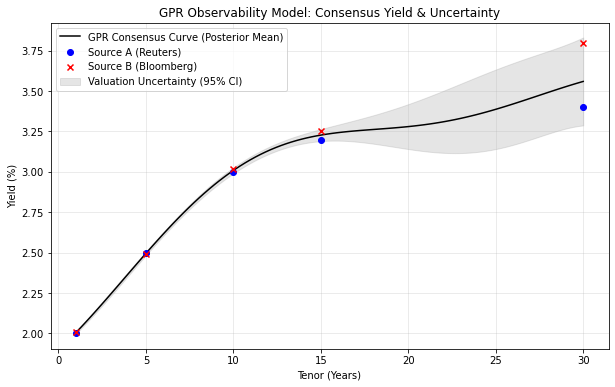

30Y Consensus Yield: 3.560%
30Y Pricing Uncertainty (1 Std Dev): 13.9 bps


In [4]:
tenors = np.array([1, 5, 10, 15, 30])

# Assume a standard upward sloping yield curve (in %)
yields_A = np.array([2.00, 2.50, 3.00, 3.20, 3.40])
# Source B has some micro-structural noise and a large outlier at 30Y
yields_B = np.array([2.01, 2.49, 3.02, 3.25, 3.80])

# Simulated spreads (in bps) 
spreads_bps = np.array([0.76, 1.39, 1.87, 2.23, 6.43])

# Run the GPR
X_plot, y_mean, y_std, X_train, y_train = calculate_ipv_uncertainty(
    tenors, yields_A, yields_B, spreads_bps
)

# Plotting the results
plt.figure(figsize=(10, 6))

# Plot the original quotes
plt.scatter(X_train[:5], y_train[:5], c='blue',
            label='Source A (Reuters)', zorder=10)
plt.scatter(X_train[5:], y_train[5:], c='red',
            marker='x', label='Source B (Bloomberg)', zorder=10)

# Plot the GPR Consensus Curve
plt.plot(X_plot, y_mean, 'k-', label='GPR Consensus Curve (Posterior Mean)')

# Plot the Uncertainty Band (95% Confidence Interval = 1.96 * std)
plt.fill_between(X_plot.ravel(),
                 y_mean - 1.96 * y_std,
                 y_mean + 1.96 * y_std,
                 alpha=0.2, color='gray', label='Valuation Uncertainty (95% CI)')

plt.title("GPR Observability Model: Consensus Yield & Uncertainty")
plt.xlabel("Tenor (Years)")
plt.ylabel("Yield (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# The ultimate output for the risk manager:
print(f"30Y Consensus Yield: {y_mean[-1]:.3f}%")
print(f"30Y Pricing Uncertainty (1 Std Dev): {y_std[-1] * 100:.1f} bps")


Stress Test

--- RAPPORT BATCH IPV : NOEUD 30 ANS ---
Jour  | Consensus  | Ecart A-B  | Spread   | MDU (1 StdDev)  | Charge AVA (€) 
---------------------------------------------------------------------------
J1    | 3.410 %   |   2.0 bps  |  2.0 bps |  99.98 bps       | 6,398,843 €
J2    | 3.420 %   |   2.0 bps  |  2.0 bps |  99.98 bps       | 6,398,890 €
J3    | 3.405 %   |   1.0 bps  |  1.8 bps |  72.79 bps       | 4,658,839 €
J4    | 3.425 %   |   1.0 bps  |  2.2 bps |  85.43 bps       | 5,467,469 €
J5    | 3.524 %   |   5.0 bps  |  5.5 bps | 262.53 bps       | 16,801,759 €
J6    | 3.490 %   |   2.0 bps  |  3.5 bps | 142.48 bps       | 9,118,492 €
J7    | 3.460 %   |   2.0 bps  |  2.5 bps | 113.17 bps       | 7,242,823 €
J8    | 3.470 %   |   2.0 bps  |  2.0 bps |  99.98 bps       | 6,398,987 €
J9    | 3.455 %   |   1.0 bps  |  3.0 bps | 111.78 bps       | 7,154,009 €
J10   | 3.472 %   |  40.0 bps  | 10.0 bps | 1425.75 bps       | 91,248,205 €
J11   | 3.481 %   |  30.0 bps  |  8.5 bps | 1086.67

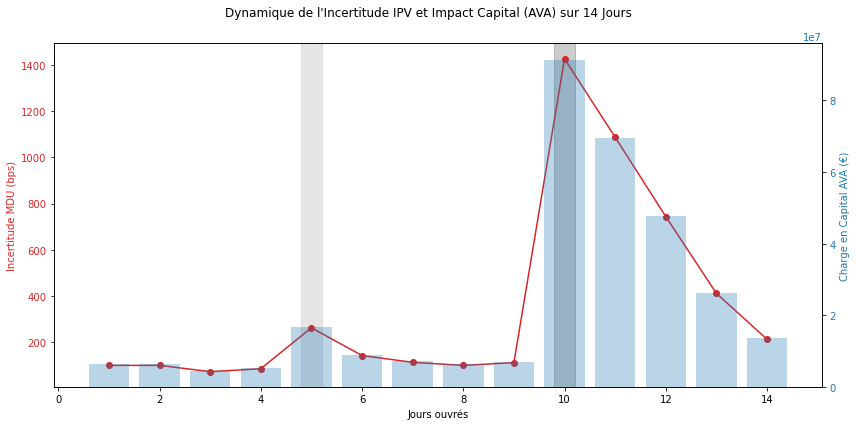

In [ ]:

# ==========================================
# 1. Jeu de Données (14 jours x 5 maturités)
# Colonnes : [1Y, 5Y, 10Y, 15Y, 30Y]
# ==========================================
tenors = np.array([1, 5, 10, 15, 30])

# Source A (Reuters) - Taux en %
yields_A_history = pd.read_csv("Data_Reuters")

# Source B (Bloomberg) - Taux en %
yields_B_history = pd.read_csv("Data_Bloomberg")

# Spreads Bid-Ask (en points de base)
spreads_history = np.array([
    [0.5, 1.0, 1.5, 1.8, 2.0],
    [0.5, 1.0, 1.5, 1.8, 2.0],
    [0.4, 0.9, 1.4, 1.7, 1.8],
    [0.6, 1.1, 1.6, 2.0, 2.2],
    [1.5, 2.5, 3.5, 4.5, 5.5],
    [1.0, 2.0, 2.5, 3.0, 3.5],
    [0.7, 1.2, 1.8, 2.2, 2.5],
    [0.5, 1.0, 1.5, 1.8, 2.0],
    [0.8, 1.5, 2.0, 2.5, 3.0],
    [2.0, 4.0, 6.0, 8.0, 10.0],  # FOMC
    [1.8, 3.5, 5.0, 7.0, 8.5],
    [1.5, 3.0, 4.5, 6.0, 7.0],
    [1.2, 2.5, 3.5, 5.0, 6.0],
    [0.8, 1.5, 2.5, 3.5, 4.5],
])

# Portefeuille du Trader 
DV01_30Y = 50000  # Dollar Value
CONFIDENCE_MULTIPLIER = 1.28  # 90% Regulatory Confidence

jours = np.arange(1, 15)
historique_mdu_30y = []
historique_ava_30y = []

print("--- RAPPORT BATCH IPV : NOEUD 30 ANS ---")
print(f"{'Jour':<5} | {'Consensus':<10} | {'Ecart A-B':<10} | {'Spread':<8} | {'MDU (1 StdDev)':<15} | {'Charge AVA (€)':<15}")
print("-" * 75)

for i in range(14):
    # Extraction des données du jour i
    y_A = yields_A_history[i]
    y_B = yields_B_history[i]
    spr = spreads_history[i]

    # Appel de votre fonction GPR (assurez-vous qu'elle retourne bien y_mean et y_std)
    _, y_mean, y_std, _, _ = calculate_ipv_uncertainty(tenors, y_A, y_B, spr)

    # Extraction des métriques pour le noeud 30 ans (le dernier point de la courbe)
    consensus_30y = y_mean[-1]
    mdu_30y_bps = y_std[-1] * 10000  # Conversion de % en bps

    # Calcul de la divergence brute pour le log
    ecart_ab_bps = abs(y_A[-1] - y_B[-1]) * 100
    spread_30y = spr[-1]

    # Calcul de l'AVA
    ava_charge = mdu_30y_bps * CONFIDENCE_MULTIPLIER * DV01_30Y

    historique_mdu_30y.append(mdu_30y_bps)
    historique_ava_30y.append(ava_charge)

    print(f"J{i+1:<4} | {consensus_30y:.3f} %   | {ecart_ab_bps:>5.1f} bps  | {spread_30y:>4.1f} bps | {mdu_30y_bps:>6.2f} bps       | {ava_charge:,.0f} €")

# ==========================================
# 3. Visualisation de la crise
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Jours ouvrés')
ax1.set_ylabel('Incertitude MDU (bps)', color='tab:red')
ax1.plot(jours, historique_mdu_30y, marker='o',
         color='tab:red', label='Market Data Uncertainty (30Y)')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.axvspan(4.8, 5.2, color='gray', alpha=0.2, label='Choc NFP')
ax1.axvspan(9.8, 10.2, color='black', alpha=0.2, label='Choc FOMC')

ax2 = ax1.twinx()
ax2.set_ylabel('Charge en Capital AVA (€)', color='tab:blue')
ax2.bar(jours, historique_ava_30y, alpha=0.3,
        color='tab:blue', label='Déduction P&L (AVA)')
ax2.tick_params(axis='y', labelcolor='tab:blue')

fig.suptitle(
    "Dynamique de l'Incertitude IPV et Impact Capital (AVA) sur 14 Jours")
fig.tight_layout()
plt.show()